In [1]:
import pytorch3d
import pytorch3d.structures
import torch
import matplotlib.pyplot as plt
import pytorch3d.renderer
import pytorch3d.io
import numpy

In [2]:
verts, faces, aux= pytorch3d.io.load_obj("data/UFO_Empty.obj")
textures = (verts - verts.min()) / (verts.max() - verts.min())
textures = pytorch3d.renderer.TexturesVertex(textures.unsqueeze(0))
meshes = pytorch3d.structures.Meshes(verts=[verts], faces=[faces.verts_idx], textures=textures)

In [3]:
R, T = pytorch3d.renderer.look_at_view_transform(dist=5.0, elev=30.0, azim=30.0, up=((0.2, 1, 0),))
camera = pytorch3d.renderer.FoVPerspectiveCameras(R=R, T=T, fov=80)
lights = pytorch3d.renderer.DirectionalLights(ambient_color=((0.5, 0.0, 0.5),), direction=((1, 1, 0),))
renderer = pytorch3d.renderer.MeshRenderer(rasterizer=pytorch3d.renderer.MeshRasterizer() , shader=pytorch3d.renderer.HardPhongShader(cameras=camera, lights=lights))

In [4]:
rend = renderer(meshes, cameras=camera, lights=lights)

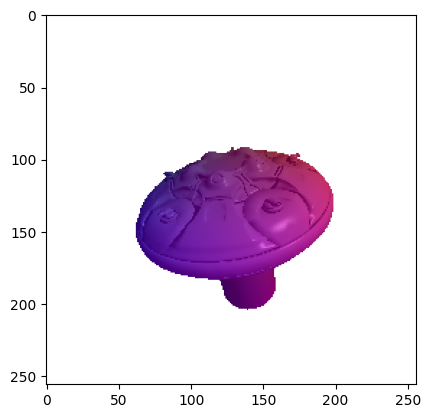

In [5]:
plt.plot(figsize=(10,10))
plt.imshow(rend.squeeze(0))

In [41]:
y_translate_seq = list(numpy.linspace(-10, 10, 20))  + list(numpy.linspace(10, -10, 20))
swing_translate_seq = list(numpy.linspace(0.25, -0.25, 20)) + list(numpy.linspace(-0.25, 0.25, 20))
azim_seq = numpy.linspace(0, 360, 40)

In [42]:
frames = []
for i in range(40):
    y_t = y_translate_seq[i]
    s_t = swing_translate_seq[i]
    a_s = azim_seq[i]
    R, T = pytorch3d.renderer.look_at_view_transform(dist=5.0, elev=30.0 + y_t, azim=a_s, up=((s_t, 1, 0),))
    camera = pytorch3d.renderer.FoVPerspectiveCameras(R=R, T=T, fov=80)
    lights = pytorch3d.renderer.DirectionalLights(ambient_color=((0.5, 0.0, 0.5),), direction=((1, 1, 0),))
    renderer = pytorch3d.renderer.MeshRenderer(rasterizer=pytorch3d.renderer.MeshRasterizer() , shader=pytorch3d.renderer.HardPhongShader(cameras=camera, lights=lights))
    rend = renderer(meshes, cameras=camera, lights=lights)
    frames.append((rend[0, ..., :3].numpy() * 255).astype(numpy.uint8))

In [43]:
import imageio
imageio.mimwrite("ufo.gif", frames, duration=1000/20, loop=0)

In [38]:
y_translate_seq.__len__()

40